In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from IPython.display import Image, Markdown

from uq_pet.config import CONFIGS_DIR, load_config
from uq_pet.data import sentence_key, split_pool_test, tag_ids_to_labels

cfg = load_config(CONFIGS_DIR / "grid_full.yaml")
cfg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ExperimentConfig(budgets=[10, 25, 50, 100], strategies=['random', 'uncertainty:mean_token_entropy', 'uncertainty:sequence_entropy', 'uncertainty:jaccard_distance'], repeats=5, llm=LLMScoreConfig(model='meta-llama/llama-3-8b-instruct', num_samples=5, temperature=0.7, max_tokens=1500, seed=3407, max_concurrency=8, max_retries=3), train=TrainConfig(checkpoint='distilbert-base-cased', epochs=20, batch_size=8, learning_rate=5e-05, weight_decay=0.01, warmup_fraction=0.1, max_length=256))

## Data

In [ ]:
from uq_pet.data import download_pet_ner

pd.set_option("display.max_columns", 100)

download_pet_ner()  # no-op if data/raw/ already has the file
pool, test = split_pool_test(seed=cfg.llm.seed)
by_key = {sentence_key(ex): ex for ex in pool}
print(f"pool: {len(pool)} sentences   test: {len(test)} sentences")

example = pool[1]
pd.DataFrame({"token": example["tokens"], "tag": tag_ids_to_labels(example["ner-tags"])}).T

pool: 333 sentences   test: 84 sentences


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
token,If,the,MSPO,sends,the,bill,for,the,temporary,continuation,of,the,measurement,to,the,GO,",",the,GO,examines,the,bill,.
tag,B-XOR Gateway,B-Actor,I-Actor,B-Activity,B-Activity Data,I-Activity Data,I-Activity Data,I-Activity Data,I-Activity Data,I-Activity Data,I-Activity Data,I-Activity Data,I-Activity Data,O,B-Actor,I-Actor,O,B-Actor,I-Actor,B-Activity,B-Activity Data,I-Activity Data,O


In [4]:
from uq_pet.viz import plot_ner_heatmap

plot_ner_heatmap(pool)

## 1. LLM sampling

Each pool sentence is tagged K=5 times by `meta-llama/llama-3-8b-instruct` at temperature 0.7

In [5]:
from uq_pet.llm_scoring import load_cache, score_pool

cache = load_cache(cfg.llm.cache_path())
missing = [ex for ex in pool if sentence_key(ex) not in cache]
print(f"cache: {len(cache)} sentences at {cfg.llm.cache_path()} ({len(missing)} missing)")

if missing:
    cache = await score_pool(cfg.llm, pool)

cache: 333 sentences at results/llm_scores/meta-llama_llama-3-8b-instruct_k5_t0.7_seed3407.jsonl (0 missing)


In [22]:
record = cache[sentence_key(pool[1])]
print(" ".join(record["tokens"]))
pd.DataFrame(
    [record["gt_tags"], *record["parsed_samples"]],
    index=["gold", *[f"sample {i + 1}" for i in range(len(record["parsed_samples"]))]],
    columns=record["tokens"],
)

If the MSPO sends the bill for the temporary continuation of the measurement to the GO , the GO examines the bill .


,If,the,MSPO,sends,the,bill,for,the,temporary,continuation,of,the,measurement,to,the,GO,",",the,GO,examines,the,bill,.
gold,B-XOR Gateway,B-Actor,I-Actor,B-Activity,B-Activity Data,I-Activity Data,I-Activity Data,I-Activity Data,I-Activity Data,I-Activity Data,I-Activity Data,I-Activity Data,I-Activity Data,O,B-Actor,I-Actor,O,B-Actor,I-Actor,B-Activity,B-Activity Data,I-Activity Data,O
sample 1,B-XOR Gateway,B-Condition Specification,B-Actor,B-Activity,B-Activity Data,I-Activity Data,B-Further Specification,B-Condition Specification,I-Further Specification,I-Further Specification,I-Condition Specification,I-Condition Specification,I-Activity Data,O,I-Activity Data,B-Actor,O,I-Activity Data,I-Actor,B-Activity,B-Activity Data,I-Activity Data,O
sample 2,B-XOR Gateway,B-Condition Specification,B-Actor,B-Activity,B-Activity Data,I-Activity Data,B-Further Specification,I-Condition Specification,I-Further Specification,I-Further Specification,I-Activity Data,I-Activity Data,I-Activity Data,O,I-Activity Data,B-Actor,O,I-Activity Data,I-Actor,B-Activity,B-Activity Data,I-Activity Data,O
sample 3,B-XOR Gateway,B-Activity Data,B-Actor,B-Activity,B-Activity Data,I-Activity Data,B-Further Specification,B-Activity Data,I-Further Specification,I-Further Specification,I-Activity Data,I-Activity Data,I-Activity Data,O,B-Activity Data,B-Actor,O,B-Activity Data,I-Actor,B-Activity,B-Activity Data,I-Activity Data,O
sample 4,B-XOR Gateway,B-Condition Specification,B-Actor,B-Activity,B-Activity Data,I-Activity Data,B-Further Specification,B-Activity Data,I-Activity Data,I-Activity Data,I-Activity Data,I-Activity Data,I-Activity Data,O,B-Activity Data,B-Actor,O,B-Activity Data,B-Actor,B-Activity,B-Activity Data,I-Activity Data,O
sample 5,B-XOR Gateway,B-Activity Data,B-Actor,B-Activity,I-Activity Data,I-Activity Data,B-Further Specification,I-Activity Data,I-Further Specification,I-Further Specification,I-Activity Data,I-Activity Data,I-Activity Data,O,I-Activity Data,B-Actor,O,I-Activity Data,I-Actor,B-Activity,I-Activity Data,I-Activity Data,O


## 2. uncertainty metrics

In [7]:
from uq_pet.uncertainty import METRICS

scores = pd.DataFrame({
    name: {key: fn(rec["parsed_samples"]) for key, rec in cache.items()}
    for name, fn in METRICS.items()
})
scores.describe().round(3)

,sequence_entropy,mean_token_entropy,max_token_entropy,variation_ratio,jaccard_distance
count,333.000,333.000,333.000,333.000,333.000
mean,1.992,0.533,1.475,0.178,0.414
std,0.556,0.256,0.478,0.089,0.163
min,-0.000,0.000,-0.000,0.000,0.000
25%,1.922,0.356,1.371,0.117,0.318
50%,2.322,0.537,1.522,0.178,0.438
75%,2.322,0.704,1.922,0.236,0.530
max,2.322,1.214,2.322,0.443,0.733


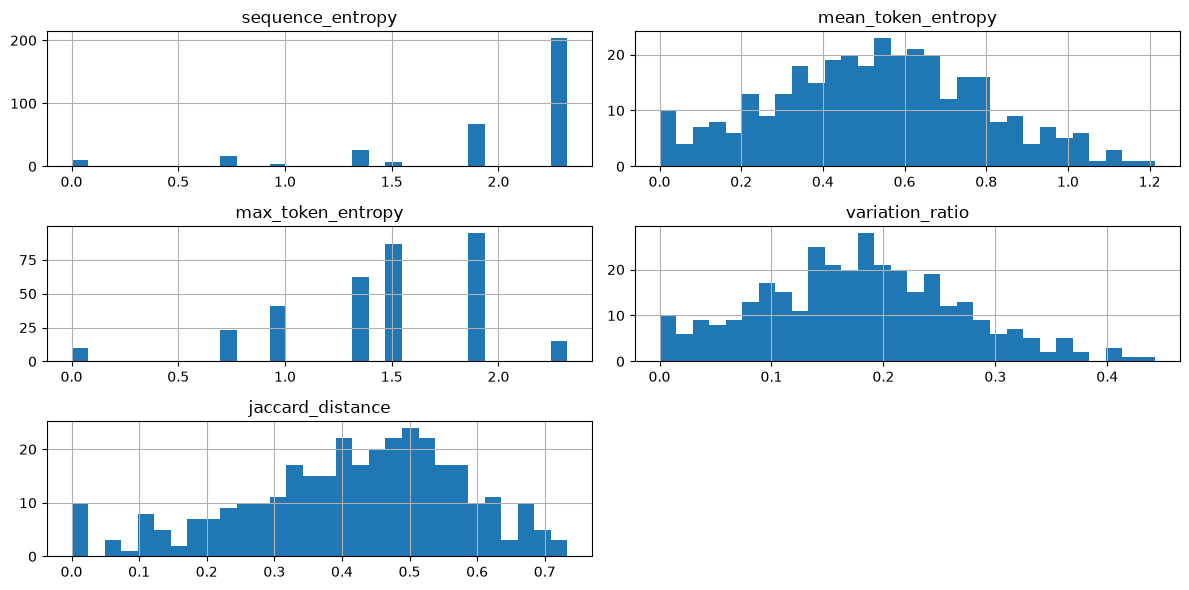

In [8]:
import matplotlib.pyplot as plt

scores.hist(bins=30, figsize=(12, 6))
plt.tight_layout()

In [9]:
metric = "mean_token_entropy"
key = scores[metric].idxmax()
rec = cache[key]
print(f"most uncertain by {metric} ({scores.loc[key, metric]:.3f}):")
pd.DataFrame(
    [rec["gt_tags"], *rec["parsed_samples"]],
    index=["gold", *[f"sample {i + 1}" for i in range(len(rec["parsed_samples"]))]],
    columns=rec["tokens"],
)

most uncertain by mean_token_entropy (1.214):


,For,each,of,these,patients,",",the,first,and,second,...,team-leader,and,the,attending,psychiatrist,formulate,a,treatment,plan,.
gold,O,O,O,O,O,O,B-Actor,I-Actor,I-Actor,I-Actor,...,I-Actor,I-Actor,I-Actor,I-Actor,I-Actor,B-Activity,B-Activity Data,I-Activity Data,I-Activity Data,O
sample 1,B-Actor,I-Actor,I-Condition Specification,O,B-Actor,O,B-Activity Data,I-Activity Data,B-AND Gateway,I-Activity Data,...,I-Actor,B-AND Gateway,B-Activity Data,I-Actor,I-Actor,B-Activity,B-Activity Data,I-Activity Data,I-Activity Data,O
sample 2,B-Actor,I-Actor,B-Further Specification,I-Further Specification,O,O,B-Activity Data,I-Activity Data,B-AND Gateway,I-Activity Data,...,I-Actor,B-AND Gateway,B-Activity Data,I-Actor,I-Actor,B-Activity,B-Activity Data,I-Activity Data,I-Activity Data,O
sample 3,B-Actor,I-Actor,I-AND Gateway,O,B-Actor,O,B-Activity Data,I-Activity,I-Activity,I-Activity,...,B-Actor,I-Activity,B-Activity Data,B-Actor,B-Actor,B-Activity,B-Activity Data,I-Activity Data,I-Activity Data,O
sample 4,O,O,O,O,O,O,O,O,O,O,...,O,O,O,O,O,O,O,O,O,O
sample 5,B-Further Specification,O,B-Actor,O,B-Actor,O,B-Activity Data,I-Further Specification,I-AND Gateway,I-Further Specification,...,B-Actor,I-AND Gateway,B-Activity Data,B-Actor,B-Actor,B-Activity,B-Further Specification,I-Activity,I-Activity Data,O


## 3. top-n most uncertain sentences

In [10]:
from uq_pet.selection import select

keys = list(by_key)
n = round(len(keys) * 10 / 100)  # 10% budget

random_keys = select("random", keys, None, n, seed=0)
uncertain_keys = select("uncertainty:mean_token_entropy", keys,
                        scores["mean_token_entropy"].to_dict(), n, seed=0)

def mean_len(selected):
    return sum(len(by_key[k]["tokens"]) for k in selected) / len(selected)

print(f"10% budget -> {n} sentences")
print(f"overlap between the two subsets: {len(set(random_keys) & set(uncertain_keys))}")
print(f"mean sentence length   random: {mean_len(random_keys):.1f}   "
      f"uncertainty: {mean_len(uncertain_keys):.1f}")

10% budget -> 33 sentences
overlap between the two subsets: 5
mean sentence length   random: 18.9   uncertainty: 21.2


## Mini training demo

One real fine-tune to show the mechanics: `distilbert-base-cased` on the 10%-budget uncertainty subset with the fixed grid recipe, evaluated on the held-out test split. This reproduces the recorded grid cell `budget=10|strategy=uncertainty:mean_token_entropy|seed=0` (entity F1 ≈ 0.60) — the only cell in this notebook that does real work on every run.

In [11]:
from uq_pet.evaluate import evaluate_model_on
from uq_pet.train import train_token_classifier

model, tokenizer = train_token_classifier([by_key[k] for k in uncertain_keys], cfg.train, seed=0)
metrics = evaluate_model_on(model, tokenizer, list(test), cfg.train)
del model
{k: v for k, v in metrics.items() if k != "per_type_f1"}

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1/20 loss=2.7582
  epoch 5/20 loss=1.4367
  epoch 10/20 loss=0.4711
  epoch 15/20 loss=0.1648
  epoch 20/20 loss=0.1107


{'entity_f1': 0.5975609756097561,
 'entity_precision': 0.5337690631808278,
 'entity_recall': 0.6786703601108033,
 'token_accuracy': 0.7130434782608696}

## 4. full grid sweep

In [12]:
import logging

from uq_pet.experiment import create_run_dir, resume_run_dir, run_grid

logging.basicConfig(level=logging.INFO, format="%(message)s")

run_dir = create_run_dir(cfg, "grid_full")
# ... or reuse a completed run instead of retraining:
# cfg, run_dir = resume_run_dir("legacy_20260710")
run_grid(cfg, run_dir)

Grid: 65 cells (65 already recorded)
[1/65] skip (done): budget=10|strategy=random|seed=0
[2/65] skip (done): budget=10|strategy=random|seed=1
[3/65] skip (done): budget=10|strategy=random|seed=2
[4/65] skip (done): budget=10|strategy=random|seed=3
[5/65] skip (done): budget=10|strategy=random|seed=4
[6/65] skip (done): budget=10|strategy=uncertainty:mean_token_entropy|seed=0
[7/65] skip (done): budget=10|strategy=uncertainty:mean_token_entropy|seed=1
[8/65] skip (done): budget=10|strategy=uncertainty:mean_token_entropy|seed=2
[9/65] skip (done): budget=10|strategy=uncertainty:mean_token_entropy|seed=3
[10/65] skip (done): budget=10|strategy=uncertainty:mean_token_entropy|seed=4
[11/65] skip (done): budget=10|strategy=uncertainty:sequence_entropy|seed=0
[12/65] skip (done): budget=10|strategy=uncertainty:sequence_entropy|seed=1
[13/65] skip (done): budget=10|strategy=uncertainty:sequence_entropy|seed=2
[14/65] skip (done): budget=10|strategy=uncertainty:sequence_entropy|seed=3
[15/65] 

## 5. results summary

In [13]:
from uq_pet.reporting import load_runs, plot_learning_curves, summary_table

figures_dir = run_dir / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
runs = load_runs(run_dir / "records.jsonl")
print(f"{len(runs)} recorded runs")
Markdown(summary_table(runs))

65 recorded runs


| Budget | Strategy | Entity F1 (mean±std) | ΔF1 vs random | Token acc | Mean sent. len |
|--------|----------|----------------------|---------------|-----------|----------------|
| 10% | random | 0.5732 ± 0.0119 | — | 0.7077 | 18.3 |
| 10% | uncertainty:jaccard_distance | 0.5745 ± 0.0115 | +0.0013 | 0.7065 | 20.7 |
| 10% | uncertainty:mean_token_entropy | 0.6020 ± 0.0042 | +0.0288 | 0.7133 | 21.2 |
| 10% | uncertainty:sequence_entropy | 0.6157 ± 0.0227 | +0.0425 | 0.7414 | 17.3 |
| 25% | random | 0.6967 ± 0.0165 | — | 0.7763 | 18.3 |
| 25% | uncertainty:jaccard_distance | 0.6832 ± 0.0073 | -0.0136 | 0.7920 | 21.0 |
| 25% | uncertainty:mean_token_entropy | 0.6937 ± 0.0140 | -0.0031 | 0.7933 | 21.1 |
| 25% | uncertainty:sequence_entropy | 0.7033 ± 0.0122 | +0.0065 | 0.7735 | 19.1 |
| 50% | random | 0.7429 ± 0.0106 | — | 0.8005 | 18.1 |
| 50% | uncertainty:jaccard_distance | 0.7468 ± 0.0057 | +0.0039 | 0.8148 | 21.1 |
| 50% | uncertainty:mean_token_entropy | 0.7531 ± 0.0039 | +0.0102 | 0.8171 | 20.8 |
| 50% | uncertainty:sequence_entropy | 0.7438 ± 0.0183 | +0.0009 | 0.7945 | 19.3 |
| 100% | full pool | 0.7759 ± 0.0104 | — | 0.8297 | 17.9 |

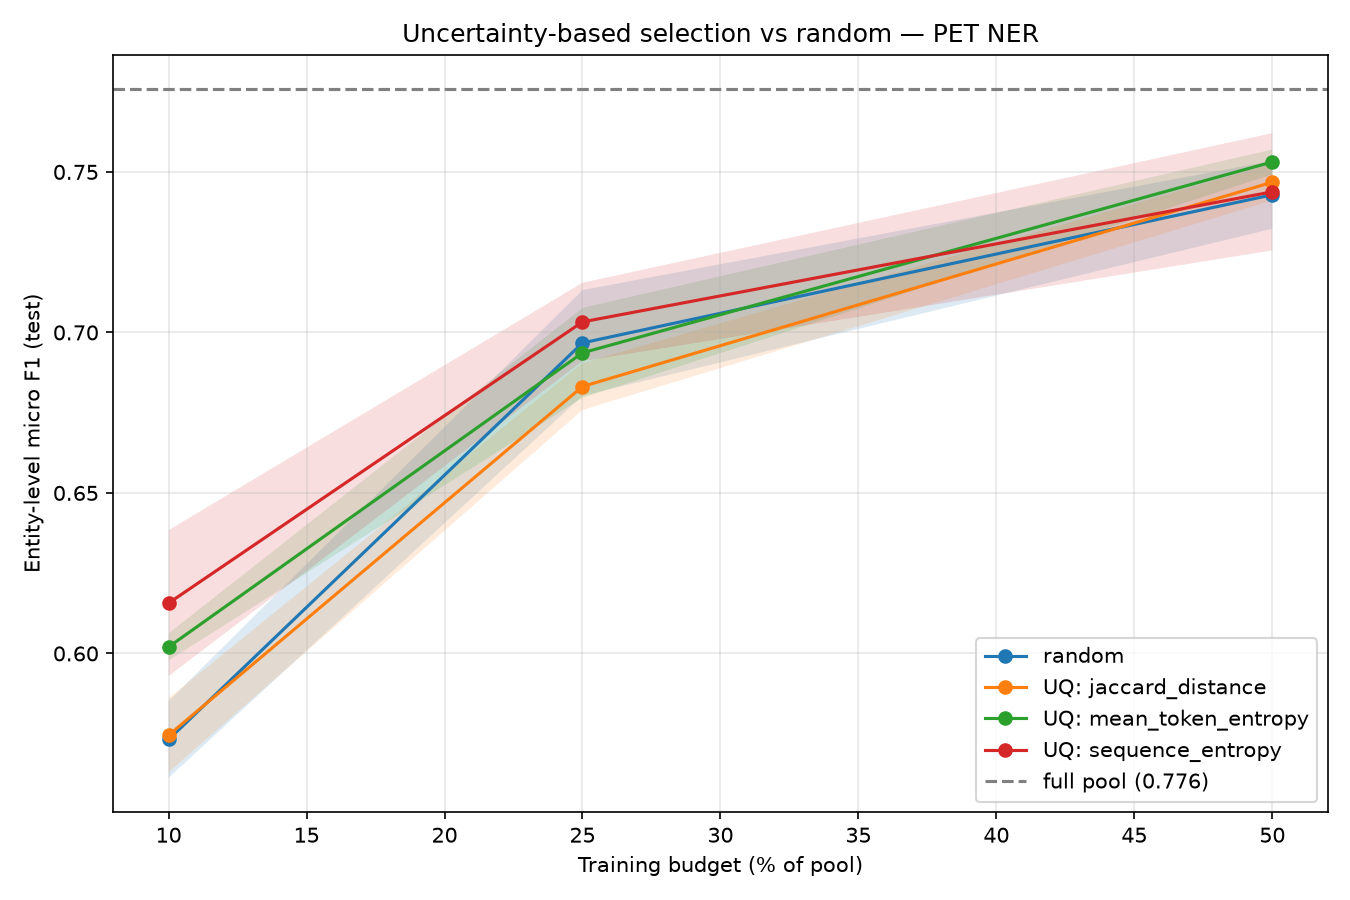

In [14]:
plot_learning_curves(runs, figures_dir / "learning_curves.png")
Image(filename=str(figures_dir / "learning_curves.png"))